In [1]:
#imports

import joblib #Used to save and load trained model to a file
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split #Splits data into training and testing chunks 
from sklearn.ensemble import RandomForestRegressor #The ML model 
from sklearn.metrics import mean_absolute_error, r2_score #Ways to measure how accurate the model is

In [2]:
#Load saved CSVs
weather = pd.read_csv("weather.csv")
eia_df = pd.read_csv("eia.csv")

#Converts to actual date/time type  
weather["datetime"] = pd.to_datetime(weather["datetime"])
eia_df["datetime"] = pd.to_datetime(eia_df["datetime"])

#Join the two together on datetime column.  
merged_df = pd.merge(weather, eia_df, on="datetime", how="inner") #inner means only keep rows where both tables have a matching timestamp

#Shows first five rows of the table
merged_df.head()

,temperature,humidity,apparent_temperature,datetime,hour,month,demand_mwh
0,8.1,77,5.0,2022-01-01 00:00:00,0,1,22618.0
1,6.3,79,3.4,2022-01-01 01:00:00,1,1,24545.0
2,5.2,77,2.4,2022-01-01 02:00:00,2,1,27081.0
3,5.0,76,2.1,2022-01-01 03:00:00,3,1,27153.0
4,3.7,80,0.8,2022-01-01 04:00:00,4,1,26522.0


In [3]:
#Drops rows with demand_mwh missing
merged_df = merged_df.dropna(subset=["demand_mwh"])
merged_df = merged_df.dropna() #Drops rows with any missing values 

#Creates a new column called heatwave_flag
merged_df["heatwave_flag"] = (merged_df["temperature"] >= 32).astype(int) #checks if the temperature is 32°C or above
merged_df["is_weekend"] = pd.to_datetime(merged_df["datetime"]).dt.dayofweek >= 5 #Creates another column and checks of the day is Saturday or Sunday, result is either true or false. 

#Calculates the 70th and 90th percentile of electricity demand across the whole dataset. Become the thresholds for Low/Medium/High risk
p70 = merged_df["demand_mwh"].quantile(0.70)
p90 = merged_df["demand_mwh"].quantile(0.90) #demand level that only 10% of hours ever exceeded, a high-demand hour

#function that takes a single demand value and returns a risk label
def label_risk(demand):
    #Above the 90th percentile = High
    if demand >= p90:
        return "High"
    #Between 70th and 90th = Medium
    elif demand >= p70:
        return "Medium"
    #Below 70th = Low
    return "Low"

#Creates a new column, risk_level where the results are stored after the function is run on every row in the table
merged_df["risk_level"] = merged_df["demand_mwh"].apply(label_risk)

#A list of all the columns the model is allowed to use as inputs when making predictions.
features = [
    "temperature",
    "humidity",
    "apparent_temperature",
    "hour",
    "month",
    "heatwave_flag",
    "is_weekend",
]


X = merged_df[features].astype(float) #The input (the 7 weather/time features). .astype(float) converts everything to numbers so the model can process it.
y = merged_df["demand_mwh"] #What is being predicted (electricity demand)

In [4]:
#Randomly splits data into training and testing sets. 80% for training the model (X_train, Y_train), and 20% used for testing (X_test, Y_test) 
#The model never sees the test set during training, it's used later to check accuracy on data the model hasn't seen.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42 #Uses the same random split every time
)

In [5]:
#Creates a Random Forest model with 100 decision trees (n_estimators=100), then trains it on the training data
#"Training" means the model looks at all the historical weather + demand rows and learns patterns 
#like "when temperature is high and it's 6 PM, demand tends to be high."
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [6]:
#Uses the trained model to predict demand for the test set.
y_pred = model.predict(X_test)

In [7]:
#Two ways to measure how accurate the model is.
print("MAE:", mean_absolute_error(y_test, y_pred)) #MAE (Mean Absolute Error) is the average gap between predicted and actual demand in MWh, lower is better.
print("R²:", r2_score(y_test, y_pred)) #R² goes from 0 to 1 and measures how much of the variation in demand the model explains, closer to 1 is better.

MAE: 1168.269236883281
R²: 0.8797299427337002


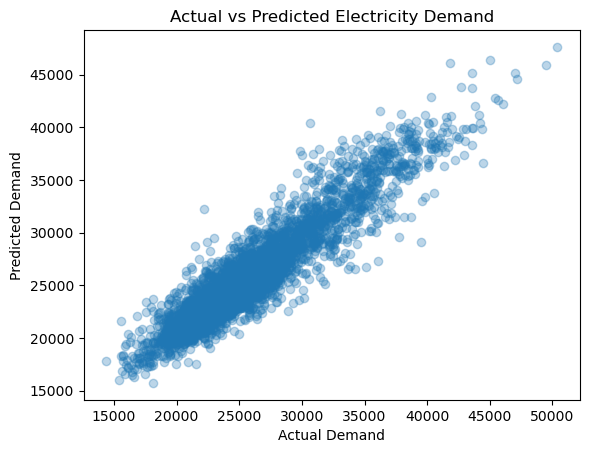

In [8]:
#Draws a chart where each dot is a single hour
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Demand") #Real demand
plt.ylabel("Predicted Demand") #Model predicted 
plt.title("Actual vs Predicted Electricity Demand")
plt.show()

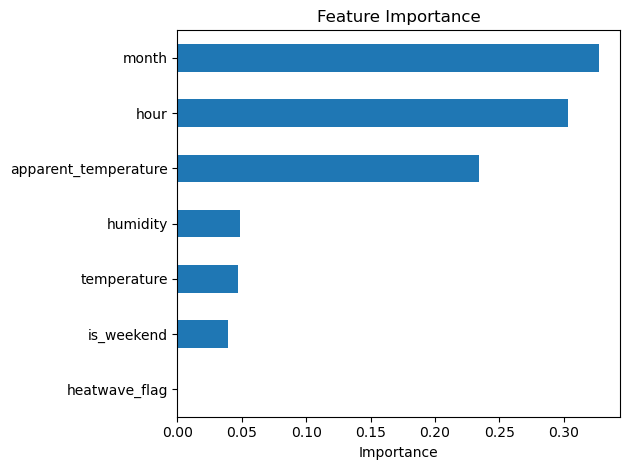

In [9]:
#After training, the Random Forest knows which inputs mattered most

importances = pd.Series(model.feature_importances_, index=features) #model.feature_importances_ gives you a score for each feature
importances.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [10]:
# Save model and thresholds for use in app.py
joblib.dump(model, "model.pkl") #trained model itself, a frozen snapshot of everything the model learned
joblib.dump({"p70": p70, "p90": p90, "features": features}, "model_meta.pkl") #saves the risk thresholds (p70, p90) and the feature list
print("Model saved to model.pkl")
print(f"Risk thresholds — p70: {p70:.0f} MWh, p90: {p90:.0f} MWh")

Model saved to model.pkl
Risk thresholds — p70: 26475 MWh, p90: 31868 MWh
